# Medical RE Benchmark — Results Analysis

Visualizes and compares results from medre-bench experiments, including ROC-AUC.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# RESULTS_DIR = Path("../outputs")
RESULTS_DIR = Path("/Users/basel.alshaikhdeeb/Documents/outputs2")

In [2]:
def collect_results(results_dir: Path) -> pd.DataFrame:
    """Collect all metrics.json files into a DataFrame, including ROC-AUC + precision/recall."""
    records = []
    for metrics_file in results_dir.rglob("metrics.json"):
        with open(metrics_file) as f:
            data = json.load(f)
        config = data.get("config", {})
        eval_m = data.get("eval", {})

        def pick(*keys):
            for k in keys:
                if k in eval_m and eval_m[k] is not None:
                    return eval_m[k]
            return None

        records.append({
            "model": config.get("model", "unknown"),
            "dataset": config.get("dataset", "unknown"),
            "seed": config.get("seed", 0),
            "micro_f1": pick("eval_micro_f1", "micro_f1"),
            "macro_f1": pick("eval_macro_f1", "macro_f1"),
            "weighted_f1": pick("eval_weighted_f1", "weighted_f1"),
            "micro_precision": pick("eval_micro_precision", "micro_precision"),
            "macro_precision": pick("eval_macro_precision", "macro_precision"),
            "micro_recall": pick("eval_micro_recall", "micro_recall"),
            "macro_recall": pick("eval_macro_recall", "macro_recall"),
            "accuracy": pick("eval_accuracy", "accuracy"),
            # Binary AUC
            "roc_auc": pick("eval_roc_auc", "roc_auc"),
            # Multi-class one-vs-rest
            "roc_auc_macro": pick("eval_roc_auc_macro", "roc_auc_macro"),
            "roc_auc_weighted": pick("eval_roc_auc_weighted", "roc_auc_weighted"),
        })
    df = pd.DataFrame(records)
    # Unify AUC into a single column for plotting (binary -> roc_auc, else macro)
    df["auc"] = df["roc_auc_macro"].combine_first(df["roc_auc"])
    return df

df = collect_results(RESULTS_DIR)
print(f"Found {len(df)} experiment runs")
df.sort_values("dataset")

Found 655 experiment runs


,model,dataset,seed,micro_f1,macro_f1,weighted_f1,micro_precision,macro_precision,micro_recall,macro_recall,accuracy,roc_auc,roc_auc_macro,roc_auc_weighted,auc
164,roberta-base,bc5cdr,123,0.947456,0.837318,0.947818,0.947456,0.832755,0.947456,0.842046,0.947456,0.973924,NaN,NaN,0.973924
280,gpt2,bc5cdr,123,0.942652,0.822444,0.943047,0.942652,0.818083,0.942652,0.826965,0.942652,0.956239,NaN,NaN,0.956239
360,roberta-large,bc5cdr,42,0.950202,0.843835,0.950229,0.950202,0.843454,0.950202,0.844217,0.950202,0.942682,NaN,NaN,0.942682
61,pubmedbert,bc5cdr,456,0.952818,0.856392,0.953535,0.952818,0.845977,0.952818,0.867661,0.952818,0.976143,NaN,NaN,0.976143
60,roberta-large,bc5cdr,123,0.948657,0.840057,0.948855,0.948657,0.837462,0.948657,0.842704,0.948657,0.974829,NaN,NaN,0.974829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,gpt2,gad,7919,0.735744,0.734189,0.734387,0.735744,0.739971,0.735744,0.735069,0.735744,0.805158,NaN,NaN,0.805158
130,bio-clinicalbert,gad,2024,0.752434,0.751703,0.751835,0.752434,0.754434,0.752434,0.751977,0.752434,0.839013,NaN,NaN,0.839013
131,roberta-large,gad,123,0.760779,0.760612,0.760673,0.760779,0.761054,0.760779,0.760594,0.760779,0.836340,NaN,NaN,0.836340
307,clinicalbert,gad,42,0.764951,0.763190,0.763389,0.764951,0.771344,0.764951,0.764184,0.764951,0.831329,NaN,NaN,0.831329


## 1. Pivot Tables — F1 and AUC

In [3]:
df["auc_metric"] = df["auc"].fillna(df["roc_auc_weighted"])
micro_pivot = df.pivot_table(index="model", columns="dataset", values="micro_f1", aggfunc="mean")
macro_pivot = df.pivot_table(index="model", columns="dataset", values="macro_f1", aggfunc="mean")
# weightedf1_pivot = df.pivot_table(index="model", columns="dataset", values="weighted_f1", aggfunc="mean")
auc_pivot = df.pivot_table(index="model", columns="dataset", values="auc_metric", aggfunc="mean")
# roc_auc_pivot = df.pivot_table(index="model", columns="dataset", values="roc_auc", aggfunc="mean")
# auc_weighted_pivot = df.pivot_table(index="model", columns="dataset", values="roc_auc_weighted", aggfunc="mean")
# auc_macro_pivot = df.pivot_table(index="model", columns="dataset", values="roc_auc_macro", aggfunc="mean")

print("=== Micro F1 ===")
print(micro_pivot.round(3).to_string())
print("\n=== Macro F1 ===")
print(macro_pivot.round(3).to_string())
print("\n=== ROC-AUC (binary or macro one-vs-rest) ===")
print(auc_pivot.round(3).to_string())

=== Micro F1 ===
dataset            bc5cdr  biored  chem_dis_gene  chemprot    ddi  drugprot  euadr    gad
model                                                                                    
bert-base           0.944   0.772          0.978     0.965  0.981     0.960  0.943  0.759
bio-clinicalbert    0.944   0.774          0.977     0.965  0.981     0.960  0.948  0.754
biobert             0.950   0.785          0.981     0.968  0.983     0.962  0.950  0.798
biogpt              0.948   0.779          0.980     0.964  0.981     0.945  0.957  0.774
biolinkbert-base    0.954   0.792          0.981     0.970  0.984     0.959  0.954  0.794
biolinkbert-large   0.956   0.791          0.983     0.777  0.985     0.004  0.957  0.811
biomed-roberta      0.950   0.787          0.980     0.967  0.983     0.963  0.949  0.800
clinicalbert        0.944   0.773          0.977     0.965  0.980     0.960  0.947  0.760
gatortron           0.953   0.790          0.982     0.969  0.984     0.958  0.954 

## 2. Heatmaps

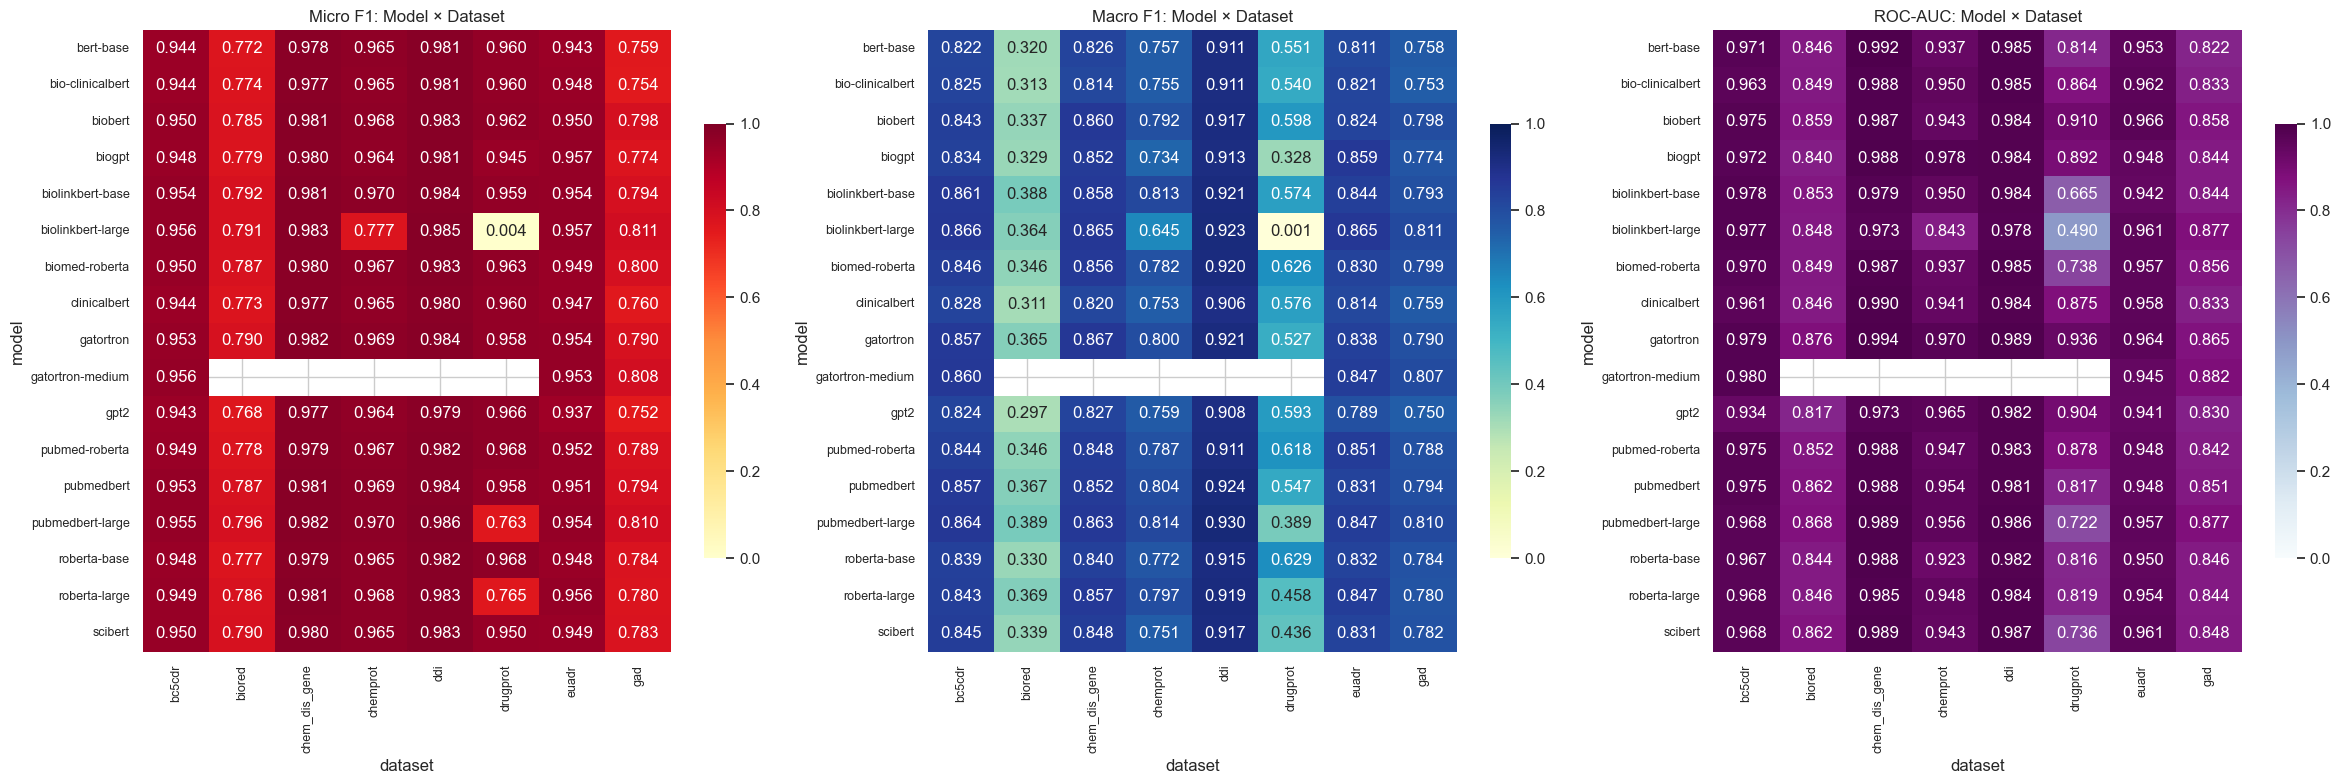

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, (title, pivot, cmap) in zip(
    axes,
    [
        ("Micro F1", micro_pivot, "YlOrRd"),
        ("Macro F1", macro_pivot, "YlGnBu"),
        ("ROC-AUC", auc_pivot, "BuPu"),
    ],
):
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax, vmin=0, vmax=1, cbar_kws={"shrink": 0.7})
    ax.set_title(f"{title}: Model × Dataset")
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig("metrics_heatmap.png", dpi=150)
plt.show()



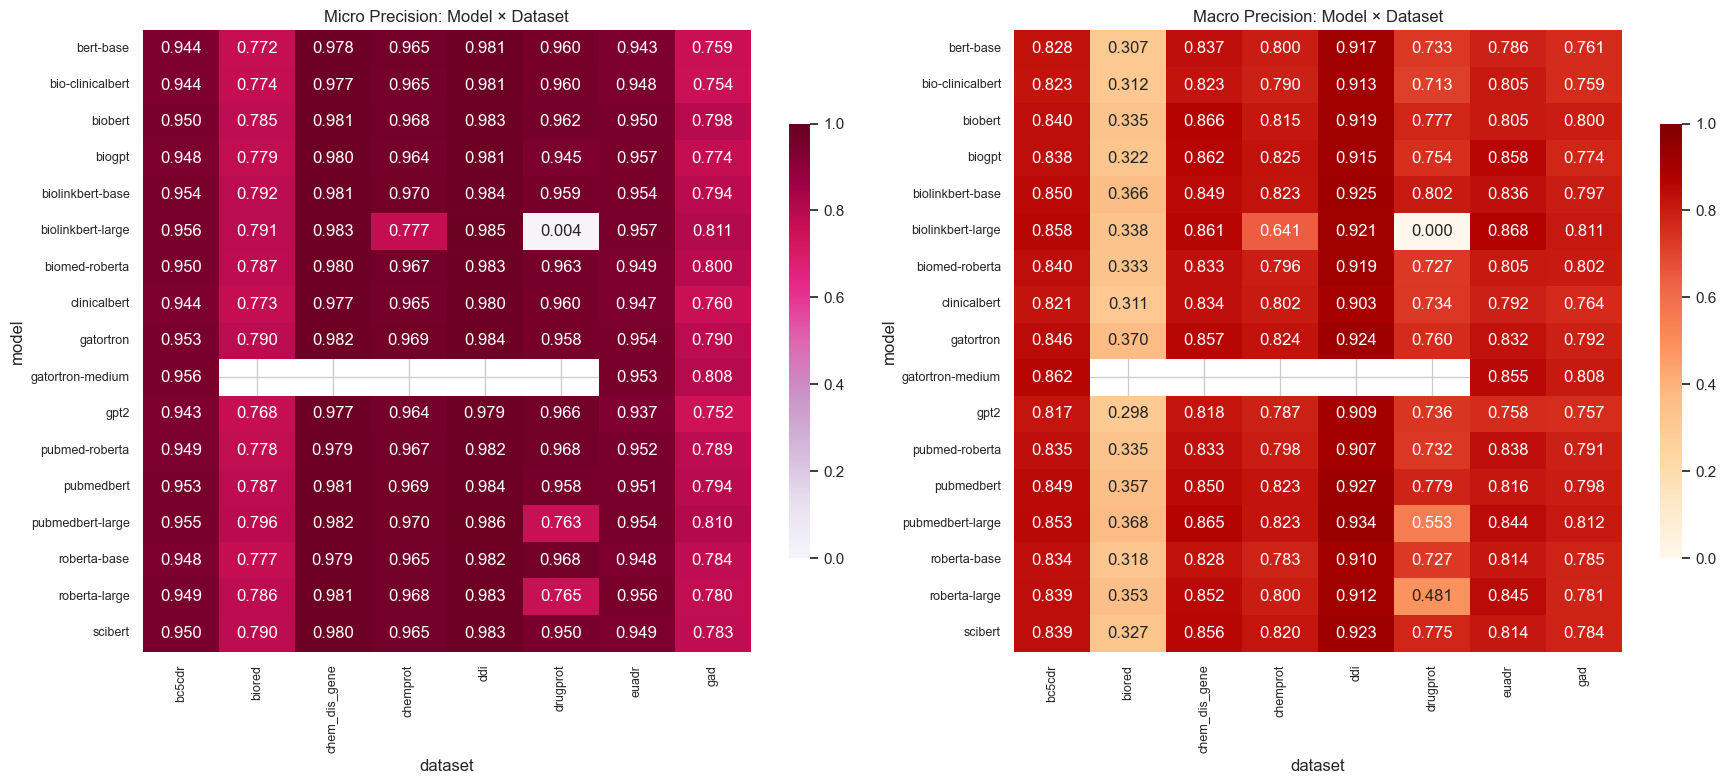

In [5]:
# ── Precision heatmaps (micro + macro) ──────────────────────────────────────
micro_precision_pivot = df.pivot_table(index="model", columns="dataset", values="micro_precision", aggfunc="mean")
macro_precision_pivot = df.pivot_table(index="model", columns="dataset", values="macro_precision", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, (title, pivot, cmap) in zip(
    axes,
    [
        ("Micro Precision", micro_precision_pivot, "PuRd"),
        ("Macro Precision", macro_precision_pivot, "OrRd"),
    ],
):
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax, vmin=0, vmax=1, cbar_kws={"shrink": 0.7})
    ax.set_title(f"{title}: Model × Dataset")
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig("precision_heatmap.png", dpi=150)
plt.show()

### Precision & Recall Heatmaps

Same model × dataset grid, split into precision and recall so you can spot patterns per-metric (e.g. high precision + low recall = model is conservative).

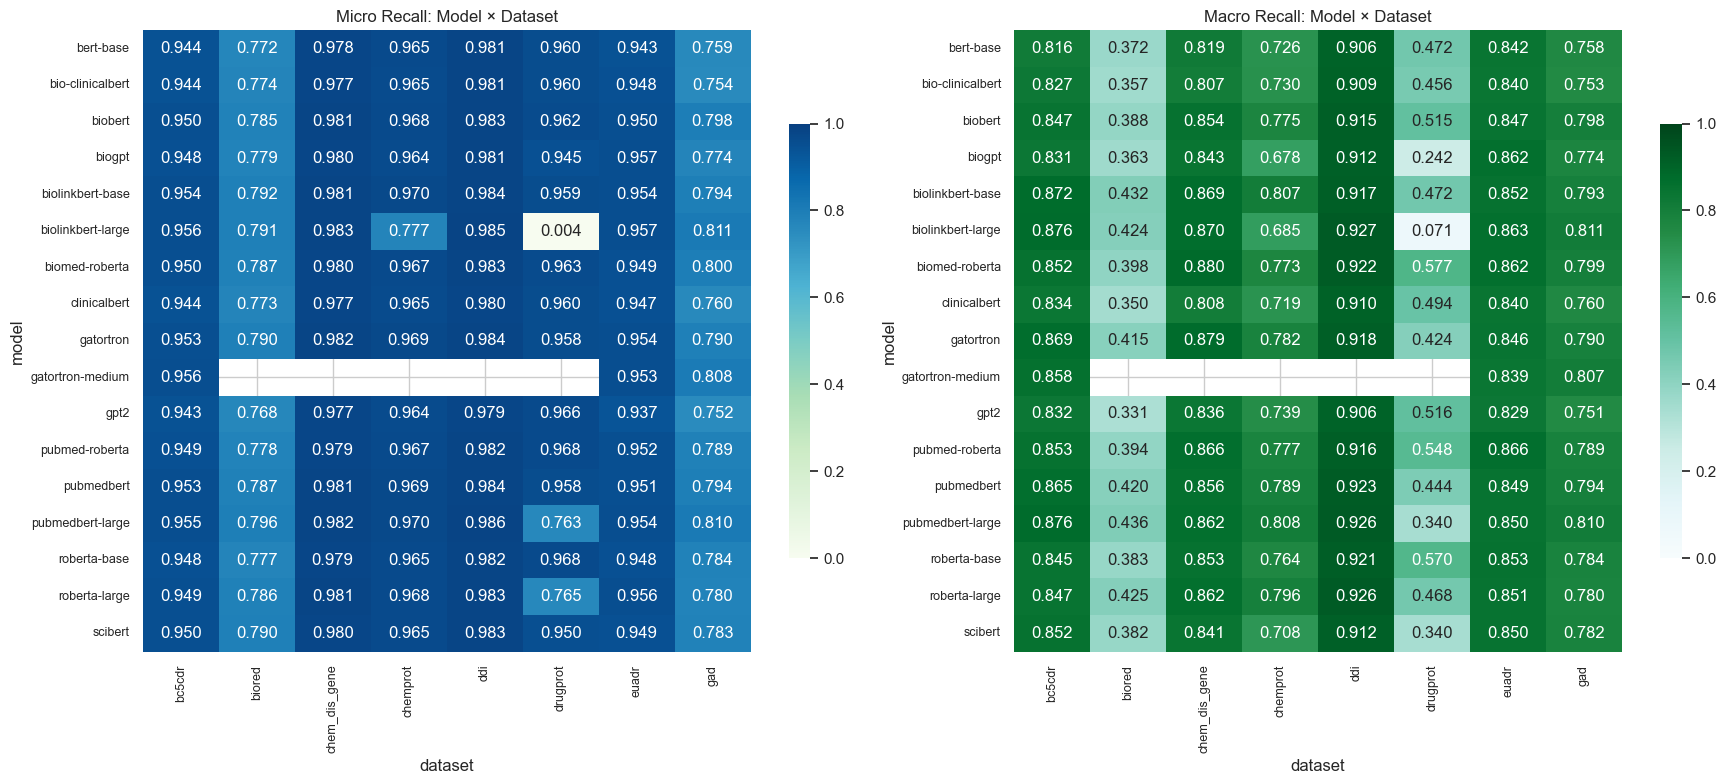

In [6]:
# ── Recall heatmaps (micro + macro) ─────────────────────────────────────────
micro_recall_pivot = df.pivot_table(index="model", columns="dataset", values="micro_recall", aggfunc="mean")
macro_recall_pivot = df.pivot_table(index="model", columns="dataset", values="macro_recall", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, (title, pivot, cmap) in zip(
    axes,
    [
        ("Micro Recall", micro_recall_pivot, "GnBu"),
        ("Macro Recall", macro_recall_pivot, "BuGn"),
    ],
):
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax, vmin=0, vmax=1, cbar_kws={"shrink": 0.7})
    ax.set_title(f"{title}: Model × Dataset")
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig("recall_heatmap.png", dpi=150)
plt.show()

## 3. Per-Dataset Comparison (Micro F1, Macro F1, ROC-AUC)

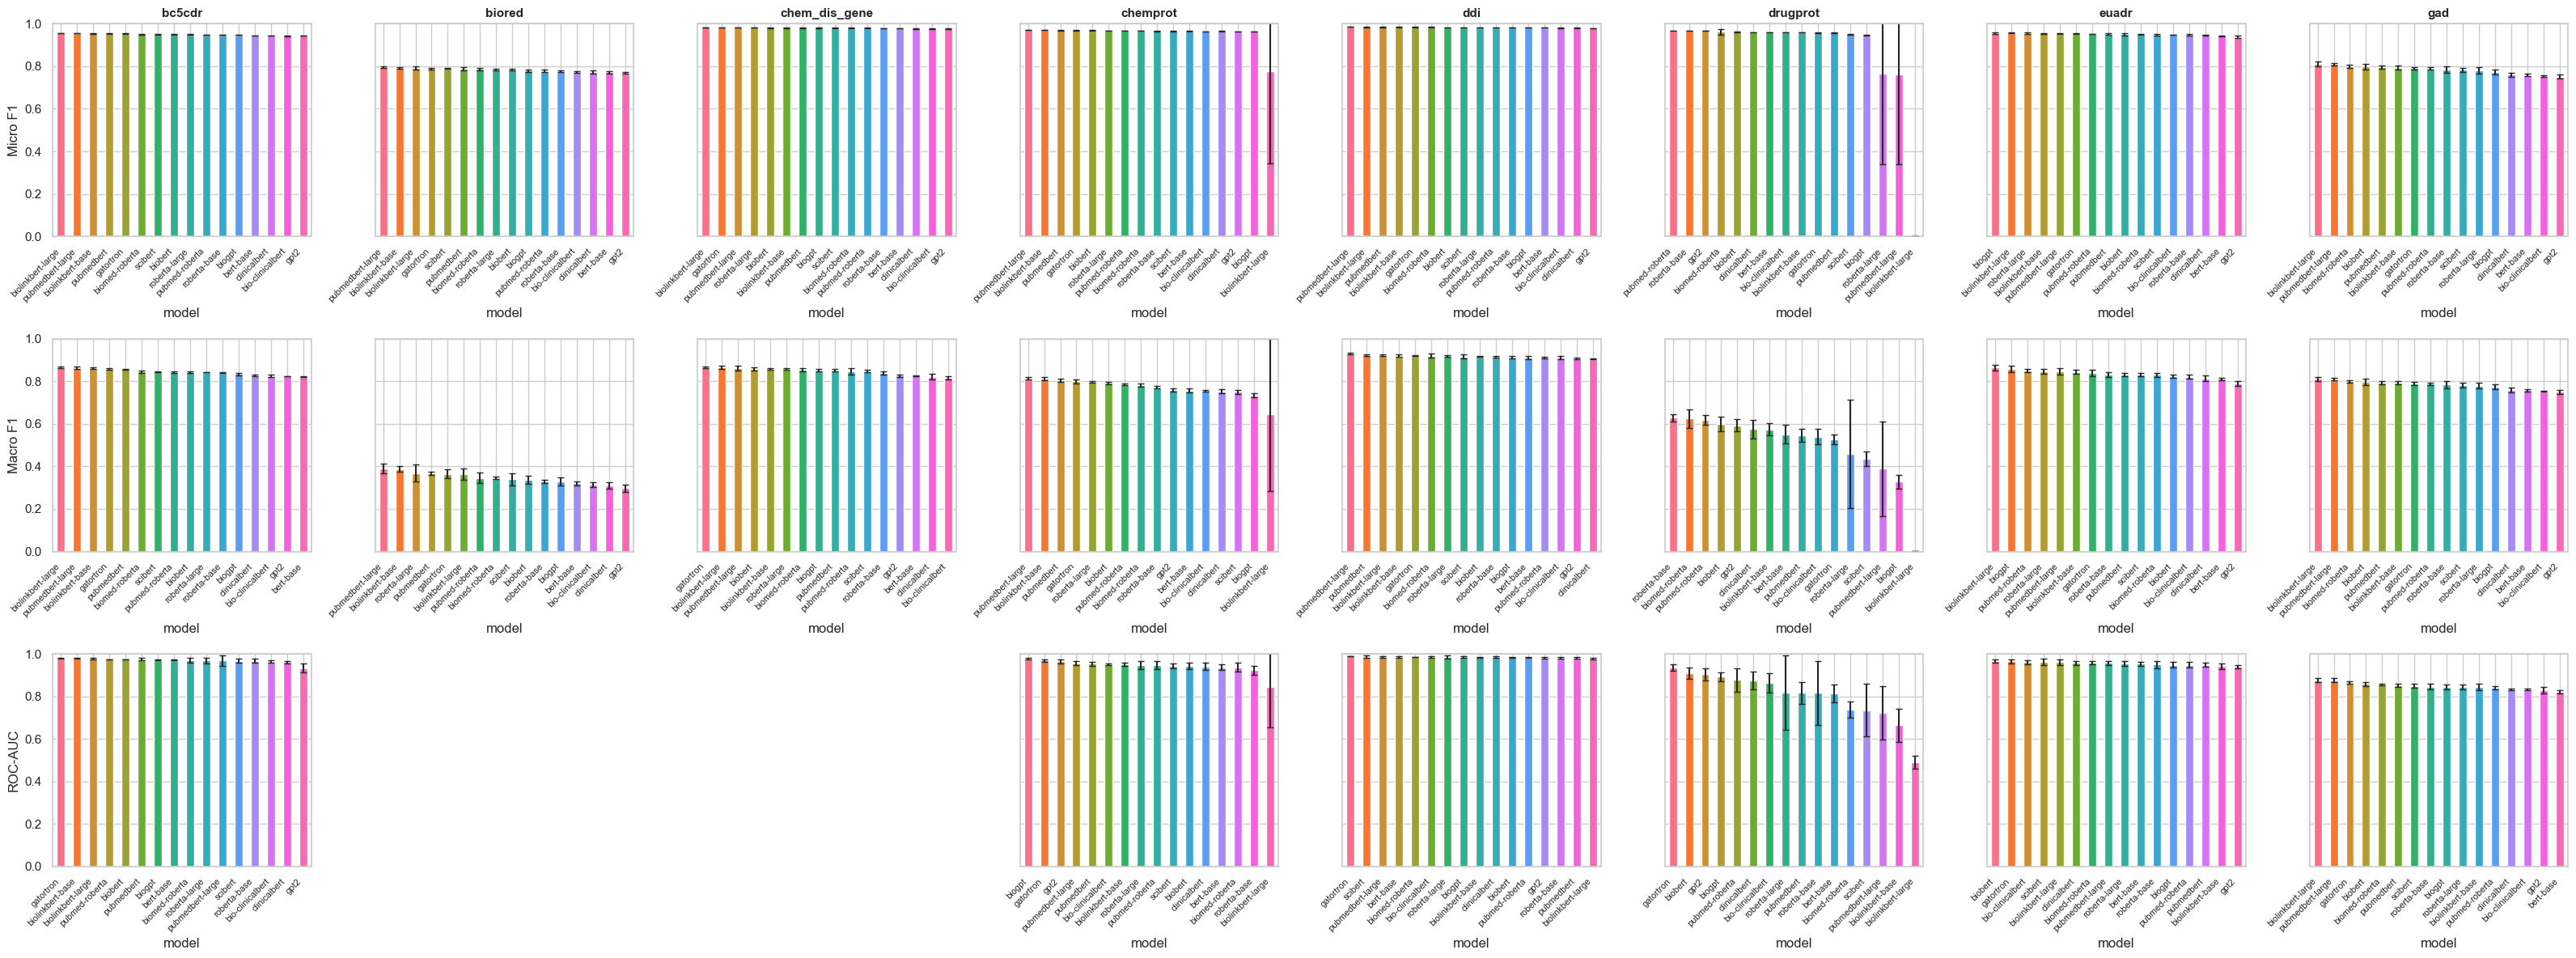

In [4]:
datasets_sorted = sorted(df["dataset"].unique())
metrics_to_plot = [
    ("micro_f1", "Micro F1"),
    ("macro_f1", "Macro F1"),
    ("auc", "ROC-AUC"),
]

fig, axes = plt.subplots(
    len(metrics_to_plot), len(datasets_sorted),
    figsize=(4 * len(datasets_sorted), 4 * len(metrics_to_plot)),
    sharey="row",
)

for row_idx, (metric_key, metric_label) in enumerate(metrics_to_plot):
    for col_idx, dataset in enumerate(datasets_sorted):
        ax = axes[row_idx, col_idx]
        subset = df[df["dataset"] == dataset]
        means = subset.groupby("model")[metric_key].mean().dropna().sort_values(ascending=False)
        if means.empty:
            ax.set_visible(False)
            continue
        stds = subset.groupby("model")[metric_key].std().reindex(means.index).fillna(0)

        means.plot(
            kind="bar", ax=ax, yerr=stds, capsize=3,
            color=sns.color_palette("husl", len(means)),
        )
        if row_idx == 0:
            ax.set_title(dataset, fontsize=11, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(metric_label)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
        ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("per_dataset_comparison.png", dpi=150)
plt.show()

## 4. Macro F1 vs ROC-AUC

Macro F1 punishes minority-class errors hard; ROC-AUC measures ranking quality regardless of decision threshold. Big gaps between the two suggest threshold-tuning could help.

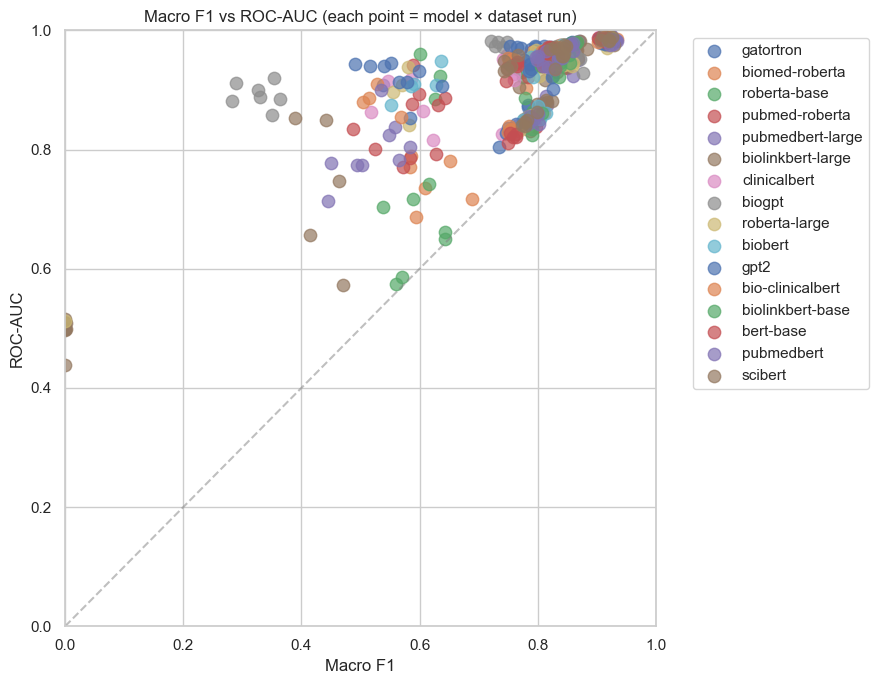

In [5]:
df_auc = df.dropna(subset=["auc", "macro_f1"])

fig, ax = plt.subplots(figsize=(9, 7))
for model in df_auc["model"].unique():
    subset = df_auc[df_auc["model"] == model]
    ax.scatter(subset["macro_f1"], subset["auc"], label=model, s=80, alpha=0.7)

ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
ax.set_xlabel("Macro F1")
ax.set_ylabel("ROC-AUC")
ax.set_title("Macro F1 vs ROC-AUC (each point = model × dataset run)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("macro_f1_vs_auc.png", dpi=150)
plt.show()

## 5. Micro F1 vs Macro F1

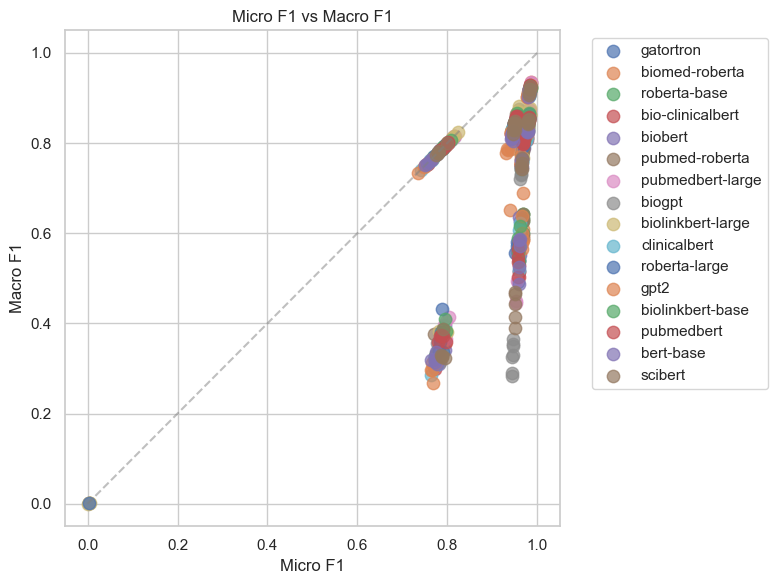

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for model in df["model"].unique():
    subset = df[df["model"] == model]
    ax.scatter(subset["micro_f1"], subset["macro_f1"], label=model, s=80, alpha=0.7)

ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
ax.set_xlabel("Micro F1")
ax.set_ylabel("Macro F1")
ax.set_title("Micro F1 vs Macro F1")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("micro_vs_macro_f1.png", dpi=150)
plt.show()

## 6. Best Model per Dataset (by ROC-AUC)

In [7]:
best_rows = []
for dataset in sorted(df["dataset"].unique()):
    subset = df[df["dataset"] == dataset].dropna(subset=["auc"])
    if subset.empty:
        continue
    means = subset.groupby("model").agg({
        "micro_f1": "mean",
        "macro_f1": "mean",
        "auc": "mean",
    })
    best = means.sort_values("auc", ascending=False).head(1).reset_index()
    best.insert(0, "dataset", dataset)
    best_rows.append(best)

best_df = pd.concat(best_rows, ignore_index=True) if best_rows else pd.DataFrame()
best_df.round(3)

,dataset,model,micro_f1,macro_f1,auc
0,bc5cdr,gatortron,0.953,0.857,0.979
1,chemprot,biogpt,0.964,0.734,0.978
2,ddi,gatortron,0.984,0.921,0.989
3,drugprot,gatortron,0.958,0.527,0.936
4,euadr,biobert,0.950,0.824,0.966
5,gad,biolinkbert-large,0.811,0.811,0.877


## 7. Average Rank Across Datasets

Aggregate model performance across all datasets by ranking models within each dataset and averaging.

In [8]:
rank_metrics = ["micro_f1", "macro_f1", "auc"]
rank_df = (
    df.groupby(["model", "dataset"])[rank_metrics].mean().reset_index()
)

ranks = (
    rank_df.set_index(["dataset", "model"])[rank_metrics]
    .groupby(level="dataset")
    .rank(ascending=False, method="min")
)
avg_ranks = ranks.groupby(level="model").mean().sort_values("auc")

print("Average rank across datasets (lower = better):")
avg_ranks.round(2)

Average rank across datasets (lower = better):


,micro_f1,macro_f1,auc
model,,,
gatortron,5.38,5.50,1.67
biobert,6.50,7.25,5.67
biogpt,10.38,10.88,6.83
pubmedbert-large,3.75,3.62,7.00
scibert,9.00,10.25,8.00
bio-clinicalbert,13.00,13.50,8.33
biomed-roberta,6.75,6.38,8.67
roberta-large,8.00,7.25,8.67
pubmed-roberta,8.12,7.38,9.17


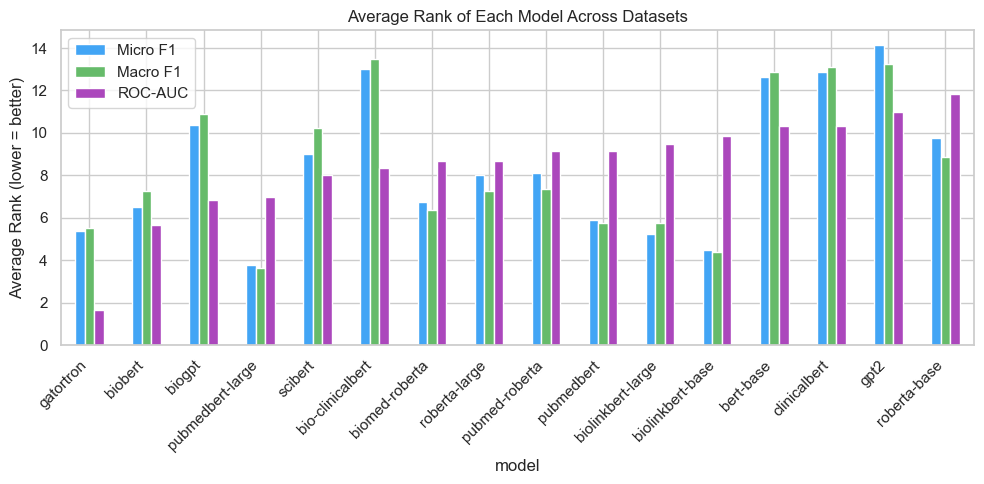

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
avg_ranks.plot(kind="bar", ax=ax, color=["#42A5F5", "#66BB6A", "#AB47BC"])
ax.set_ylabel("Average Rank (lower = better)")
ax.set_title("Average Rank of Each Model Across Datasets")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(["Micro F1", "Macro F1", "ROC-AUC"], loc="best")
plt.tight_layout()
plt.savefig("avg_rank.png", dpi=150)
plt.show()

## 8. Per-Class Detail Table (TP / FP / TN / FN / Precision / Recall)

Select a `model` and a `dataset`. The notebook loads that run's best checkpoint from `RESULTS_DIR`, runs inference on the dataset's validation split, and computes a per-class confusion breakdown (one row per label) with TP, FP, TN, FN, precision, recall, F1, and support.

**First run for a `(model, dataset)` pair is slow** (loads the model + tokenizes + scores the whole val split — ~30 s–2 min depending on dataset size). Subsequent selections are instant: results are cached under `RESULTS_DIR/_per_class_cache/`.

If multiple seeds exist for a `(model, dataset)`, confusion matrices are summed across seeds so precision/recall reflect the combined behavior.

In [7]:
from __future__ import annotations
import hashlib
import os
import warnings
from collections import defaultdict
import time

import ipywidgets as widgets
from IPython.display import display
from tqdm.auto import tqdm

CACHE_DIR = RESULTS_DIR / "_per_class_cache"
CACHE_DIR.mkdir(exist_ok=True)

# Set to True to force CPU inference (e.g. HPC GPU incompatible with installed torch build)
FORCE_CPU = False


def _find_checkpoint_dirs(model: str, dataset: str) -> list[Path]:
    """Return every .../checkpoints/best directory under RESULTS_DIR for this
    (model, dataset) pair, across all seeds and timestamps."""
    hits: list[Path] = []
    for run_dir in RESULTS_DIR.iterdir():
        if not run_dir.is_dir():
            continue
        parts = run_dir.name.split("__")
        if len(parts) < 3 or parts[0] != model or parts[1] != dataset:
            continue
        for ts in run_dir.iterdir():
            if not ts.is_dir():
                continue
            best = ts / "checkpoints" / "best"
            if (best / "model.safetensors").exists() or (best / "pytorch_model.bin").exists():
                hits.append(best)
    return sorted(hits)


def _cache_key(model: str, dataset: str, split: str) -> Path:
    return CACHE_DIR / f"{model}__{dataset}__{split}.json"


def _run_inference_one_checkpoint(ckpt: Path, split: str, batch_size: int) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """Load checkpoint + score its dataset's split. Returns (y_true, y_pred, label_names)."""
    import sys, os as _os
    # Point the interpreter at the repo src/ so imports work when the notebook
    # is opened from anywhere.
    repo_root = Path(_os.path.abspath("..")).resolve()
    if str(repo_root / "src") not in sys.path:
        sys.path.insert(0, str(repo_root / "src"))
    import torch
    from torch.utils.data import DataLoader
    from transformers import AutoTokenizer, DataCollatorWithPadding
    import yaml

    import medre_bench.datasets  # noqa: F401 - trigger registration
    import medre_bench.models  # noqa: F401
    from medre_bench.datasets.preprocessing import BINARY_LABEL_NAMES, collapse_to_binary
    from medre_bench.models.base import get_entity_marker_tokens
    from medre_bench.registry import DATASET_REGISTRY, MODEL_REGISTRY
    from medre_bench.training.trainer import REModel, RETokenizedDataset

    # Walk up from checkpoints/best to find config_snapshot.yaml
    cfg_path = None
    for parent in (ckpt.parent.parent, ckpt.parent.parent.parent):
        p = parent / "config_snapshot.yaml"
        if p.exists():
            cfg_path = p
            break
    if cfg_path is None:
        raise FileNotFoundError(f"No config_snapshot.yaml near {ckpt}")
    saved = yaml.safe_load(cfg_path.read_text())
    m_cfg = saved.get("model", {})
    d_cfg = saved.get("dataset", {})

    strategy = m_cfg.get("entity_marker_strategy", "typed_entity_marker_punct")
    max_len = int(m_cfg.get("max_seq_length", 512))
    model_name = m_cfg.get("name")
    dataset_name = d_cfg.get("name")
    binary_mode = bool(d_cfg.get("binary_mode", False))

    print(f"  [{ckpt.parent.parent.name}] loading split {split!r} from {dataset_name} …", flush=True)
    t0 = time.time()
    dataset_cls = DATASET_REGISTRY.get(dataset_name)
    dset = dataset_cls()
    examples = dset.load_split(split)
    print(f"    dataset loaded: {len(examples)} examples in {time.time()-t0:.1f}s", flush=True)
    if binary_mode:
        examples = collapse_to_binary(examples)
        num_labels = 2
        label_names = list(BINARY_LABEL_NAMES)
    else:
        num_labels = dset.num_labels()
        label_names = dset.label_names()

    device = torch.device("cpu") if FORCE_CPU else torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
    print(f"    device={device}, loading model …", flush=True)
    t0 = time.time()
    try:
        tokenizer = AutoTokenizer.from_pretrained(str(ckpt))
    except Exception as exc:
        # Common cause: tokenizer.json was saved by a newer tokenizers version than what is
        # currently installed ("data did not match any variant of untagged enum ModelWrapper").
        # Fall back to the base pretrained tokenizer; safe when no special tokens were added
        # (i.e. strategies "typed_entity_marker_punct" and "typed_entity_marker").
        base_probe = MODEL_REGISTRY.get(model_name)()
        base_pretrained = base_probe.pretrained_model_name()
        print(f"    tokenizer load from checkpoint failed ({type(exc).__name__}); "
              f"falling back to base pretrained tokenizer {base_pretrained!r}", flush=True)
        tokenizer = AutoTokenizer.from_pretrained(base_pretrained)
    base_cls = MODEL_REGISTRY.get(model_name)
    base = base_cls()
    marker_tokens = get_entity_marker_tokens(strategy)
    base.build(num_labels=num_labels, entity_marker_tokens=marker_tokens if marker_tokens else None)
    base.tokenizer = tokenizer
    m = REModel(base, num_labels=num_labels)

    sf = ckpt / "model.safetensors"
    if sf.exists():
        from safetensors.torch import load_file
        state = load_file(str(sf), device=str(device))
    else:
        state = torch.load(ckpt / "pytorch_model.bin", map_location=device, weights_only=True)
    m.load_state_dict(state, strict=False)
    m.to(device).eval()
    print(f"    model loaded in {time.time()-t0:.1f}s ({sum(p.numel() for p in m.parameters())/1e6:.0f}M params)", flush=True)

    print(f"    tokenizing {len(examples)} examples …", flush=True)
    t0 = time.time()
    eval_ds = RETokenizedDataset(examples, tokenizer, max_len, strategy)
    print(f"    tokenized in {time.time()-t0:.1f}s", flush=True)
    collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="longest")
    loader = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, collate_fn=collator)

    y_true: list[int] = []
    y_pred: list[int] = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="  inference", leave=False):
            iids = batch["input_ids"].to(device)
            att = batch["attention_mask"].to(device)
            labels = batch["labels"]
            out = m(input_ids=iids, attention_mask=att)
            preds = torch.argmax(out.logits, dim=-1).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(labels.numpy().tolist())
    return np.array(y_true), np.array(y_pred), label_names


def _confusion_by_class(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    """Return array of shape (num_classes, 4) with columns [TP, FP, TN, FN]."""
    out = np.zeros((num_classes, 4), dtype=np.int64)
    for c in range(num_classes):
        tp = int(((y_true == c) & (y_pred == c)).sum())
        fp = int(((y_true != c) & (y_pred == c)).sum())
        tn = int(((y_true != c) & (y_pred != c)).sum())
        fn = int(((y_true == c) & (y_pred != c)).sum())
        out[c] = [tp, fp, tn, fn]
    return out


def compute_per_class(model: str, dataset: str, split: str = "validation", batch_size: int = 32, force: bool = False) -> pd.DataFrame:
    """Aggregate per-class TP/FP/TN/FN across every seed's checkpoint for (model, dataset).
    Cached under RESULTS_DIR/_per_class_cache/. Set force=True to recompute."""
    cache = _cache_key(model, dataset, split)
    if cache.exists() and not force:
        payload = json.loads(cache.read_text())
        return pd.DataFrame(payload["rows"])

    ckpts = _find_checkpoint_dirs(model, dataset)
    if not ckpts:
        raise FileNotFoundError(f"No best/ checkpoints for {model}__{dataset} under {RESULTS_DIR}")

    label_names: list[str] | None = None
    conf_sum: np.ndarray | None = None
    n_seeds = 0
    print(f"Found {len(ckpts)} checkpoint(s) to score. Batch size = {batch_size}.", flush=True)
    for ck_idx, ck in enumerate(ckpts, 1):
        print(f"[{ck_idx}/{len(ckpts)}] {ck}", flush=True)
        y_true, y_pred, names = _run_inference_one_checkpoint(ck, split=split, batch_size=batch_size)
        if label_names is None:
            label_names = names
            conf_sum = np.zeros((len(names), 4), dtype=np.int64)
        elif label_names != names:
            warnings.warn(f"Label mismatch for {ck}: {names} vs {label_names}. Skipping this seed.")
            continue
        conf_sum += _confusion_by_class(y_true, y_pred, len(names))
        n_seeds += 1

    rows = []
    assert conf_sum is not None and label_names is not None
    for i, name in enumerate(label_names):
        tp, fp, tn, fn = conf_sum[i].tolist()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        support = tp + fn
        rows.append({
            "class": name,
            "TP": tp, "FP": fp, "TN": tn, "FN": fn,
            "precision": round(prec, 4),
            "recall":    round(rec, 4),
            "f1":        round(f1, 4),
            "support":   support,
        })
    cache.write_text(json.dumps({"model": model, "dataset": dataset, "split": split, "n_seeds_used": n_seeds, "rows": rows}, indent=2))
    return pd.DataFrame(rows)

In [8]:
# Interactive: model + dataset dropdown -> per-class table
def _render(model: str, dataset: str, split: str, force: bool):
    from IPython.display import clear_output
    try:
        print(f"Computing / loading cached per-class metrics for {model} × {dataset} × {split} …")
        table = compute_per_class(model, dataset, split=split, force=force)
        cache_file = _cache_key(model, dataset, split)
        n_seeds_used = json.loads(cache_file.read_text()).get("n_seeds_used") if cache_file.exists() else None
        totals = {
            "TP": int(table["TP"].sum()),
            "FP": int(table["FP"].sum()),
            "TN": int(table["TN"].sum()),
            "FN": int(table["FN"].sum()),
            "support": int(table["support"].sum()),
        }
        print(f"seeds combined: {n_seeds_used}   cache: {cache_file}")
        print(f"totals: {totals}\n")
        display(table)
    except Exception as exc:
        print(f"error: {exc}")

if df.empty:
    print("No runs found — populate RESULTS_DIR first.")
else:
    model_options = sorted(df["model"].unique())
    dataset_options = sorted(df["dataset"].unique())
    model_dd = widgets.Dropdown(options=model_options, description="model:")
    dataset_dd = widgets.Dropdown(options=dataset_options, description="dataset:")
    split_dd = widgets.Dropdown(options=["validation", "test"], value="validation", description="split:")
    force_cb = widgets.Checkbox(value=False, description="recompute (ignore cache)")
    run_btn = widgets.Button(description="Run", button_style="primary")
    out_area = widgets.Output()

    def _on_click(_):
        with out_area:
            out_area.clear_output()
            _render(model_dd.value, dataset_dd.value, split_dd.value, force_cb.value)

    run_btn.on_click(_on_click)
    display(widgets.HBox([model_dd, dataset_dd, split_dd, force_cb, run_btn]), out_area)

Output()